In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
import pandas as pd
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp

In [2]:
def train(q_hp, delta_T_i, delta_T_a, q_solar, idx_night, delta_t):
    N = len(delta_T_i)
    
    # Expression
    X1 = delta_T_a*delta_t
    X2 = q_hp
    X3 = idx_night
    X4 = q_solar 
    
    Y_n = delta_T_i
     
    X_n = np.column_stack([X1, X2, X3, X4])
    lb = [0.0, 0.0, -np.inf, 0.0]
    ub = [ np.inf,  np.inf, np.inf, np.inf]

    res = lsq_linear(X_n, Y_n, bounds=(lb, ub))

    theta_n = res.x
    residuals_n = res.cost * 2   # lsq_linear reports 1/2 ||r||^2

    # recover parameters
    alpha, beta, gamma, epsilon = theta_n   # [1/(C·R), 1/C, w_n/C]
    C     = 1.0 / beta
    R_a   = beta / alpha
    w_n   = gamma * C
    eta_s   = epsilon * C
    rmse_n  = np.sqrt(residuals_n / len(Y_n))

    return C, R_a, w_n, eta_s, rmse_n

In [3]:
def train_last_chance(q_hp, delta_T_i, delta_T_a, q_solar, idx_night, delta_t):
    N = len(delta_T_i)
    
    # Expression
    X1 = delta_T_a*delta_t
    X2 = q_hp
    X3 = idx_night
    X4 = q_solar 
    
    Y_n = delta_T_i
     
    X_n = np.column_stack([X1, X2, X3, X4])
    lb = [0.0, 0.0, -np.inf, -np.inf]
    ub = [ np.inf,  np.inf, np.inf, np.inf]

    res = lsq_linear(X_n, Y_n, bounds=(lb, ub))

    theta_n = res.x
    residuals_n = res.cost * 2   # lsq_linear reports 1/2 ||r||^2

    # recover parameters
    alpha, beta, gamma, epsilon = theta_n   # [1/(C·R), 1/C, w_n/C]
    C     = 1.0 / beta
    R_a   = beta / alpha
    w_n   = gamma * C
    eta_s   = epsilon * C
    rmse_n  = np.sqrt(residuals_n / len(Y_n))

    return C, R_a, w_n, eta_s, rmse_n

In [4]:
def year_windows_from_first_ts(first_ts: pd.Timestamp):
    """
    Calendar-year window:
    - Year starts Jan 1 of first_ts.year
    - Training window is Jan 1 – Mar 31
    - Year ends Dec 31
    """
    year = first_ts.year + 1

    year_start = pd.Timestamp(year=year, month=1, day=1)
    train_end  = pd.Timestamp(year=year, month=3, day=31, hour=23, minute=59, second=59)
    year_end   = pd.Timestamp(year=year, month=12, day=31, hour=23, minute=59, second=59)

    return year_start, train_end, year_end


In [5]:
def clean_and_gate_house_year(
    df_single: pd.DataFrame,
    t_start: pd.Timestamp,
    t_train_end: pd.Timestamp,
    t_year_end: pd.Timestamp,
    # columns to gate on
    col_Ti: str = "Internal_Air_Temperature",
    col_qhp: str = "Heat_Pump_Energy_Output",
    # sampling / interpolation behavior
    enforce_freq: str | None = "30min",   # set None to avoid forcing a grid
    max_gap_steps: int = 4,               # 4*30min = 2 hours
    do_interpolate: bool = True,
    # missingness thresholds (tune)
    max_missing_year: float = 0.90,       # allow up to 90% missing in year #
        # window
    max_missing_train: float = 0.20,      # allow up to 10% missing in 
        # training window
    # minimum data requirements (optional but useful)
    min_train_points: int = 1000,         # for 30-min data ~ 21 days; tune as needed
    verbose: bool = False,
):
    diag = {}

    # 0) Ensure datetime index
    if "Timestamp" in df_single.columns:
        df = df_single.copy()
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
        df = df.dropna(subset=["Timestamp"]).set_index("Timestamp").sort_index()
        df[col_qhp] = df[col_qhp].clip(lower=0)

    else:
        # already indexed by timestamp
        df = df_single.copy()
        df.index = pd.to_datetime(df.index, errors="coerce")
        df = df.dropna(subset=[col_Ti, col_qhp], how="all").sort_index()
        df[col_qhp] = df[col_qhp].clip(lower=0)


    # 1) Slice to chosen year window
    df_year = df.loc[(df.index >= t_start) & (df.index <= t_year_end)].copy()
    if df_year.empty:
        diag.update({"reason": "empty_year_window", "n_year_rows": 0})
        return None, None, diag

    # 2) Optionally regularize to a strict grid *after* slicing
    # (do this here so you don't manufacture NaNs outside the target window)
    if enforce_freq is not None:
        # round to grid, merge duplicates, then resample
        df_year.index = df_year.index.round(enforce_freq)
        df_year = df_year.groupby(df_year.index).mean(numeric_only=True)
        df_year = df_year.resample(enforce_freq).mean()

    # 3) Training slice (Jan–Mar of the selected year)
    df_train = df_year.loc[(df_year.index >= t_start) & (df_year.index <= t_train_end)].copy()
    if df_train.empty:
        diag.update({"reason": "no_data_in_training_window", "n_train_rows": 0, "n_year_rows": len(df_year)})
        return None, None, diag

    # 4) Missingness BEFORE interpolation (only on the gating columns)
    req_cols = [c for c in [col_Ti, col_qhp] if c in df_year.columns]
    if len(req_cols) < 2:
        diag.update({"reason": "missing_required_columns", "required_cols_present": req_cols})
        return None, None, diag

    miss_year_Ti = float(df_year[col_Ti].isna().mean())
    miss_year_hp = float(df_year[col_qhp].isna().mean())
    miss_train_Ti = float(df_train[col_Ti].isna().mean())
    miss_train_hp = float(df_train[col_qhp].isna().mean())



    diag.update({
        "n_year_rows": len(df_year),
        "n_train_rows": len(df_train),
        "miss_year_before": {col_Ti: miss_year_Ti, col_qhp: miss_year_hp},
        "miss_train_before": {col_Ti: miss_train_Ti, col_qhp: miss_train_hp},
    })

    # 5) Gate: if too much missing data, skip this house
    if (miss_train_Ti > max_missing_train) or (miss_train_hp > max_missing_train):
        diag["reason"] = "missingness_threshold_exceeded_train"
        return None, None, diag

    # 6) Interpolate short gaps (numeric only), then drop remaining NaNs in required cols
    df_filled = df_year.copy()
    if do_interpolate:
        num_cols = df_filled.select_dtypes(include=["number"]).columns
        df_filled[num_cols] = df_filled[num_cols].interpolate(
            method="time",
            limit=max_gap_steps,
            limit_direction="both",
        )

    df_year_clean = df_filled.dropna(subset=req_cols).copy()
    df_train_clean = df_year_clean.loc[(df_year_clean.index >= t_start) & (df_year_clean.index <= t_train_end)].copy()

    diag.update({
        "n_year_rows_clean": len(df_year_clean),
        "n_train_rows_clean": len(df_train_clean),
        "miss_year_after": df_year_clean[req_cols].isna().mean().to_dict(),  # should be zeros
        "miss_train_after": df_train_clean[req_cols].isna().mean().to_dict(),
    })

    # 7) Minimum training points check (optional)
    if len(df_train_clean) < min_train_points:
        diag["reason"] = "too_few_training_points"
        return None, None, diag

    diag["reason"] = "ok"
    if verbose:
        print(diag)

    return df_year_clean, df_train_clean, diag

In [6]:
df_train_detached = pd.read_parquet("retrieved_weather_data/merged_data_final_homes.parquet")
type(df_train_detached)
df_train_detached

,Unnamed: 0,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,...,Brine_Return_Temperature,Postcode,Postcode_Timestamp,temp,humidity,windspeed,solarradiation,pressure,visibility,cloudcover
0,0,EOH0005,2021-05-21 12:00:00,12:00:00,NaN,0.003,NaN,0.240,8.67,NaN,...,NaN,EH33,EH33_2021-05-21 12:00:00,9.0,94.430,26.30,84.0,990.40,5.90,96.00
1,1,EOH0005,2021-05-21 12:30:00,12:30:00,NaN,0.020,NaN,1.782,8.58,NaN,...,NaN,EH33,EH33_2021-05-21 12:30:00,9.0,94.180,26.90,77.0,990.70,6.00,96.05
2,2,EOH0005,2021-05-21 13:00:00,13:00:00,NaN,0.036,NaN,1.852,8.50,NaN,...,NaN,EH33,EH33_2021-05-21 13:00:00,9.0,93.930,27.50,70.0,991.00,6.10,96.10
3,3,EOH0005,2021-05-21 13:30:00,13:30:00,NaN,0.038,NaN,2.466,8.50,NaN,...,NaN,EH33,EH33_2021-05-21 13:30:00,8.9,93.535,26.40,67.5,991.30,6.70,92.90
4,4,EOH0005,2021-05-21 14:00:00,14:00:00,NaN,0.038,2.514,3.323,8.52,NaN,...,NaN,EH33,EH33_2021-05-21 14:00:00,8.8,93.140,25.30,65.0,991.60,7.30,89.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11113027,11113027,EOH3204,2023-03-10 09:00:00,09:00:00,NaN,NaN,NaN,NaN,2.96,NaN,...,NaN,RH18,RH18_2023-03-10 09:00:00,3.5,92.570,24.30,67.0,991.90,5.90,100.00
11113028,11113028,EOH3204,2023-03-10 09:30:00,09:30:00,NaN,NaN,NaN,NaN,2.73,NaN,...,NaN,RH18,RH18_2023-03-10 09:30:00,3.2,91.205,25.05,89.5,993.55,11.45,99.70
11113029,11113029,EOH3204,2023-03-10 10:00:00,10:00:00,NaN,NaN,NaN,NaN,2.83,NaN,...,NaN,RH18,RH18_2023-03-10 10:00:00,2.9,89.840,25.80,112.0,995.20,17.00,99.40
11113030,11113030,EOH3204,2023-03-10 10:30:00,10:30:00,NaN,NaN,NaN,NaN,3.31,NaN,...,NaN,RH18,RH18_2023-03-10 10:30:00,3.2,86.745,26.90,163.0,996.55,31.30,99.70


In [7]:
unique_ids = df_train_detached["Property_ID"].unique()

df_house = pd.read_csv('retrieved_weather_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW",
    "HP_Installed", "House_SAP"
]

df_house_train = {}
for id_use in unique_ids:
    df_house_train[id_use] = df_house[df_house["Property_ID"] == id_use]

In [8]:
missing_counts = df_house[df_house["Property_ID"].isin(unique_ids)][["Floor_Height", "Total_Floor_Area"]].isna().sum()
print(missing_counts)


Floor_Height        20
Total_Floor_Area     0
dtype: int64


In [9]:
df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

range_df_hp = (df_single .dropna(subset=["Heat_Pump_Energy_Output"]) .groupby("Property_ID")["Timestamp"] .agg(first_available="min", last_available="max") )

In [10]:
trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "HP_Type", "House_SAP",
                                     "C", "R_a", "w_s", "w_n",
                                     "rmse", "train_start", "train_end",
                                     "val_start", "val_end"])


for id_use in unique_ids:
    wall = df_house_train[id_use].Wall_Type.to_string()
    storeys = df_house_train[id_use].No_Storeys.to_string()
    floor_area = df_house_train[id_use].Total_Floor_Area.to_string()
    hp_type = df_house_train[id_use].HP_Installed.to_string()
    house_sap = df_house_train[id_use].House_SAP.to_string()

    df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

    df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
        "Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single[
        "Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] -
         df_single["Internal_Air_Temperature"])
    df_single["Immersion_Diff"] = df_single[
        "Immersion_Heater_Energy_Consumed"].diff()

    range_df_hp = (df_single.dropna(subset=["Heat_Pump_Energy_Output"]) .groupby("Property_ID")["Timestamp"] .agg(first_available="min", last_available="max") )
    first_ts = range_df_hp["first_available"].iloc[0]
    t_start, t_train_end, t_year_end = year_windows_from_first_ts(first_ts)


    #df_year = df_single[(df_single["Timestamp"] >= t_start) & ( # df_single["Timestamp"] <= t_year_end)] #df_train_3mo = df_single[(df_single["Timestamp"] >= t_start) & ( # df_single["Timestamp"] <= t_train_end)] #df_val_rest = df_single[(df_single["Timestamp"] > t_train_end) & ( # df_single["Timestamp"] <= t_year_end)]
    t_start = t_start - pd.DateOffset(months=3)
    t_train_end = t_train_end - pd.DateOffset(months=3)
    t_start_val = t_start + pd.DateOffset(months=3)
    t_end_val = t_start_val + pd.DateOffset(months=1)
    df_year_clean, df_train_clean, diag = clean_and_gate_house_year(
        df_single=df_single,
        t_start=t_start,
        t_train_end=t_train_end,
        t_year_end=t_year_end,
        col_Ti="Internal_Air_Temperature",
        col_qhp="Heat_Pump_Energy_Output_Diff",
        enforce_freq="30min",
        max_gap_steps=4,
        do_interpolate=True,
        max_missing_year=0.20,    # <-- tune
        max_missing_train=0.10,   # <-- tune
        min_train_points=1000,    # <-- tune
        verbose=False,
        )

    if df_year_clean is None:
        print("Trying 2")
        t_start = t_start + pd.DateOffset(months=3)
        t_train_end = t_train_end + pd.DateOffset(months=3)
        t_start_val = t_start + pd.DateOffset(months=3)
        t_end_val = t_start_val + pd.DateOffset(months=1)
        df_year_clean, df_train_clean, diag = clean_and_gate_house_year(
            df_single=df_single,
            t_start=t_start,
            t_train_end=t_train_end,
            t_year_end=t_year_end,
            col_Ti="Internal_Air_Temperature",
            col_qhp="Heat_Pump_Energy_Output",
            enforce_freq="30min",
            max_gap_steps=4,
            do_interpolate=True,
            max_missing_year=0.20,    # <-- tune
            max_missing_train=0.20,   # <-- tune
            min_train_points=1000,    # <-- tune
            verbose=False,
            )

    if df_year_clean is None:
        # house unusable -> move to next
        # (optional) print why:
        print(f"skip {id_use}: {diag['reason']} | miss_year={diag.get('miss_year_before')}")
        continue
    # ------ Prepare Training Data ----------
    df_heating_single = df_year_clean.copy()

    df_heating_annual = df_heating_single[df_heating_single.index >= t_start]
    df_heating_annual = df_heating_annual[df_heating_annual.index <= t_train_end]

    #df_heating_annual = df_heating_annual[
    #    (df_heating_annual.index <= t_mid_end) | (df_heating_annual
    #                                              .index >= t_mid_start)]

        # Extract hour from Timestamp
    df_heating_annual_night = df_heating_annual.copy()
    df_heating_annual_night['Hour'] = df_heating_annual.index.hour

    # Define night and day conditions
    # Condition 1: Time is between 10 PM and 6 AM
    night_time_condition = (df_heating_annual_night['Hour'] >= 20) | \
                           (df_heating_annual_night['Hour'] < 6)

    # Condition 2: Solar Irradiation is 0 (assuming 'SolarRadiation' is the correct column name)
    if 'solarradiation' in df_heating_annual_night.columns:
        night_solar_condition = (df_heating_annual_night['solarradiation'] == 0)
        df_heating_annual_night['is_night'] = night_time_condition & night_solar_condition
    else:
        print("\nWarning: 'SolarRadiation' column not found after preprocessing. Cannot use it for night/day split.")
        df_heating_annual_night['is_night'] = night_time_condition # Fallback to just time condition


    t_step = 30  # minutes
    delta_t = t_step / 60

    #Night data

    T_a = (df_heating_annual_night["temp"].iloc[:-1]
              .reset_index
           (drop=True).to_numpy())
    T_i = (df_heating_annual_night["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy())
    delta_T_a = (
        df_heating_annual_night["Internal_Ambient_Temperature_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
    delta_T_i = (df_heating_annual_night["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t)
    q_hp = (df_heating_annual_night["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy())
    q_solar = (df_heating_annual_night["solarradiation"].iloc[:-1].reset_index
               (drop=True).to_numpy())
    v_wind = (df_heating_annual_night["windspeed"].iloc[:-1].reset_index
              (drop=True)
              .to_numpy())
    q_imm = (df_heating_annual_night["Immersion_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy())

    q_tot = q_hp+q_imm
    idx_night = df_heating_annual_night['is_night'].astype(int).iloc[:-1].to_numpy()

    # Create time index for in the loop q_hat arrays
    time_index = df_heating_annual.index[:-1]
    df_q_results = pd.DataFrame(index=time_index)

    try:
        # Primary training attempt
        C, R_a, w_n, eta_s, rmse = train(
            q_hp, delta_T_i, delta_T_a, q_solar,
            idx_night, delta_t
        )

    except Exception as e1:
        try:
            # Fallback / last-chance attempt
            C, R_a, w_n, eta_s, rmse = train_last_chance(
                q_hp, delta_T_i, delta_T_a, q_solar,
                idx_night, delta_t
            )

        except Exception as e2:
            print(f"Training failed for {id_use}: primary={e1}, fallback={e2}")
            continue

    w_s = eta_s

    trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,
                              C,R_a,eta_s,w_n,rmse, t_start, t_train_end,
                              t_start_val, t_end_val]




Trying 2
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH0005: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH0021: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH0033: primary=SVD did not converge in Linear Least Squ

/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:101: RuntimeWarning: invalid value encountered in multiply
  p *= p_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:102: RuntimeWarning: invalid value encountered in multiply
  p_h *= p_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py

Trying 2
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH0279: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH0286: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Trying 2
skip EOH0355: missingness_threshold_exceeded_train | miss_year={'Internal_Air_Temperature': 0.09075765408696651, 'Heat_Pump_Energy_Output': 0.0022976621287839625}
** On entry to DLASCL, parameter 

/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:101: RuntimeWarning: invalid value encountered in multiply
  p *= p_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:102: RuntimeWarning: invalid value encountered in multiply
  p_h *= p_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf_linear.py:116: RuntimeWarning: invalid value encountered in multiply
  r_h = p_h + r_h * r_stride
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)


Trying 2


...

Trying 2
skip EOH3077: missingness_threshold_exceeded_train | miss_year={'Internal_Air_Temperature': 0.175513698630137, 'Heat_Pump_Energy_Output': 0.12151826484018265}


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_3314/425155001.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_3314/425155001.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,


Trying 2
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH3092: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_3314/425155001.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_3314/425155001.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_3314/425155001.py:162: PerformanceWarning: DataFrame is highly fragmented

** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH3186: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH3196: primary=SVD did not converge in Linear Least Squares, fallback=SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Trying 2
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
Training failed for EOH3204: primary=SVD did not converge in Linear Least Squ

In [18]:
trained_params.to_csv("trained_params_lin_regres_agg_v1.csv", index=True)
trained_params


,EOH0026,EOH0047,EOH0073,EOH0105,EOH0126,EOH0166,EOH0172,EOH0174,EOH0254,EOH0257,...,EOH3035,EOH3040,EOH3082,EOH3089,EOH3120,EOH3122,EOH3138,EOH3154,EOH3158,EOH3167
Floor Area,2966 87.0,1134 164.0,1225 113.0,2636 116.48,299 90.0,2660 61.0,2313 166.26,1861 163.97,735 111.0,686 68.0,...,1935 129.0,2657 118.0,1273 131.0,2784 139.0,2092 130.15,371 186.0,629 139.97,1149 119.44,2146 153.0,3182 191.0
No_Storeys,2966 2.0,1134 2.0,1225 2.0,2636 2.0,299 2.0,2660 1.0,2313 2.0,1861 2.0,735 1.0,686 2.0,...,1935 2.0,2657 2.0,1273 2.0,2784 2.0,2092 2.0,371 2.0,629 2.0,1149 1.0,2146 2.0,3182 2.0
Wall_Type,2966 Cavity_Insulated,1134 Cavity_Insulated,1225 Cavity_Insulated,2636 Cavity_Insulated,299 Cavity_Insulated,2660 Cavity_Insulated,2313 Cavity_Insulated,1861 Cavity_Insulated,735 Cavity_Insulated,686 Cavity_Insulated,...,1935 Cavity_Insulated,2657 Cavity_Insulated,1273 Cavity_Insulated,2784 Cavity_Insulated,2092 Cavity_Insulated,371 Cavity_Insulated,629 Cavity_Insulated,1149 Cavity_Insulated,2146 Cavity_Insulated,3182 Cavity_No_insulation
HP_Type,2966 ASHP,1134 HT_ASHP,1225 ASHP,2636 ASHP,299 ASHP,2660 ASHP,2313 HT_ASHP,1861 ASHP,735 HT_ASHP,686 ASHP,...,1935 HT_ASHP,2657 ASHP,1273 HT_ASHP,2784 ASHP,2092 ASHP,371 ASHP,629 ASHP,1149 HT_ASHP,2146 ASHP,3182 ASHP
House_SAP,2966 C,1134 NaN,1225 NaN,2636 NaN,299 NaN,2660 NaN,2313 B,1861 NaN,735 B,686 NaN,...,1935 NaN,2657 NaN,1273 C,2784 NaN,2092 NaN,371 NaN,629 NaN,1149 D,2146 NaN,3182 NaN
C,3.651877,10.378765,4.649943,6.954412,1.9352,8.342927,7.746694,8.121511,NaN,NaN,...,NaN,4.716977,3.767153,14.023004,4.745044,4.705198,3.518068,4.095637,18.747266,4.98772
R_a,4.8052,4.039747,5.182408,5.642196,6.700383,7.191656,7.641873,6.50858,NaN,NaN,...,NaN,4.399789,6.968445,3.761863,5.341805,4.46956,7.568521,3.660822,5.129894,4.785472
w_s,0.0,0.001916,0.000413,0.001774,0.0,0.000582,0.003869,0.005808,NaN,NaN,...,NaN,0.001509,0.001343,0.0,0.000859,0.0,0.001391,0.0,0.001192,0.001722
w_n,-0.081363,-0.661096,0.005648,-0.09764,0.046344,-0.203825,-1.415344,-0.25004,NaN,NaN,...,NaN,-0.264732,-0.156519,-0.13453,-0.273548,-0.319604,-0.147242,0.011699,-1.64746,-0.113824
rmse,0.280468,0.242338,0.222758,0.203562,0.436604,0.146179,0.600421,0.133798,NaN,NaN,...,NaN,0.297462,0.243143,0.179937,0.200352,0.20761,0.175447,0.251521,0.154925,0.275523


In [12]:
miss = trained_params.loc["R_a"].isna().sum()
tot = trained_params.shape[1]

tot-miss

np.int64(78)

In [13]:
trained_params

,EOH0026,EOH0047,EOH0073,EOH0105,EOH0126,EOH0166,EOH0172,EOH0174,EOH0254,EOH0257,...,EOH3035,EOH3040,EOH3082,EOH3089,EOH3120,EOH3122,EOH3138,EOH3154,EOH3158,EOH3167
Floor Area,2966 87.0,1134 164.0,1225 113.0,2636 116.48,299 90.0,2660 61.0,2313 166.26,1861 163.97,735 111.0,686 68.0,...,1935 129.0,2657 118.0,1273 131.0,2784 139.0,2092 130.15,371 186.0,629 139.97,1149 119.44,2146 153.0,3182 191.0
No_Storeys,2966 2.0,1134 2.0,1225 2.0,2636 2.0,299 2.0,2660 1.0,2313 2.0,1861 2.0,735 1.0,686 2.0,...,1935 2.0,2657 2.0,1273 2.0,2784 2.0,2092 2.0,371 2.0,629 2.0,1149 1.0,2146 2.0,3182 2.0
Wall_Type,2966 Cavity_Insulated,1134 Cavity_Insulated,1225 Cavity_Insulated,2636 Cavity_Insulated,299 Cavity_Insulated,2660 Cavity_Insulated,2313 Cavity_Insulated,1861 Cavity_Insulated,735 Cavity_Insulated,686 Cavity_Insulated,...,1935 Cavity_Insulated,2657 Cavity_Insulated,1273 Cavity_Insulated,2784 Cavity_Insulated,2092 Cavity_Insulated,371 Cavity_Insulated,629 Cavity_Insulated,1149 Cavity_Insulated,2146 Cavity_Insulated,3182 Cavity_No_insulation
HP_Type,2966 ASHP,1134 HT_ASHP,1225 ASHP,2636 ASHP,299 ASHP,2660 ASHP,2313 HT_ASHP,1861 ASHP,735 HT_ASHP,686 ASHP,...,1935 HT_ASHP,2657 ASHP,1273 HT_ASHP,2784 ASHP,2092 ASHP,371 ASHP,629 ASHP,1149 HT_ASHP,2146 ASHP,3182 ASHP
House_SAP,2966 C,1134 NaN,1225 NaN,2636 NaN,299 NaN,2660 NaN,2313 B,1861 NaN,735 B,686 NaN,...,1935 NaN,2657 NaN,1273 C,2784 NaN,2092 NaN,371 NaN,629 NaN,1149 D,2146 NaN,3182 NaN
C,3.651877,10.378765,4.649943,6.954412,1.9352,8.342927,7.746694,8.121511,NaN,NaN,...,NaN,4.716977,3.767153,14.023004,4.745044,4.705198,3.518068,4.095637,18.747266,4.98772
R_a,4.8052,4.039747,5.182408,5.642196,6.700383,7.191656,7.641873,6.50858,NaN,NaN,...,NaN,4.399789,6.968445,3.761863,5.341805,4.46956,7.568521,3.660822,5.129894,4.785472
w_s,0.0,0.001916,0.000413,0.001774,0.0,0.000582,0.003869,0.005808,NaN,NaN,...,NaN,0.001509,0.001343,0.0,0.000859,0.0,0.001391,0.0,0.001192,0.001722
w_n,-0.081363,-0.661096,0.005648,-0.09764,0.046344,-0.203825,-1.415344,-0.25004,NaN,NaN,...,NaN,-0.264732,-0.156519,-0.13453,-0.273548,-0.319604,-0.147242,0.011699,-1.64746,-0.113824
rmse,0.280468,0.242338,0.222758,0.203562,0.436604,0.146179,0.600421,0.133798,NaN,NaN,...,NaN,0.297462,0.243143,0.179937,0.200352,0.20761,0.175447,0.251521,0.154925,0.275523


In [14]:
unique_ids_trained = trained_params.columns.to_list()

In [15]:
df_single

,Unnamed: 0,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,...,humidity,windspeed,solarradiation,pressure,visibility,cloudcover,Heat_Pump_Energy_Output_Diff,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff,Immersion_Diff
11083369,11083369,EOH3204,2021-06-30 12:00:00,12:00:00,NaN,0.0,NaN,0.006,15.63,NaN,...,77.470,9.20,378.0,1017.10,44.20,83.60,NaN,NaN,NaN,NaN
11083370,11083370,EOH3204,2021-06-30 12:30:00,12:30:00,NaN,0.0,NaN,0.016,15.67,NaN,...,76.260,8.85,280.5,1017.05,39.55,83.35,NaN,NaN,-3.62,0.0
11083371,11083371,EOH3204,2021-06-30 13:00:00,13:00:00,NaN,0.0,NaN,0.028,15.70,NaN,...,75.050,8.50,183.0,1017.00,34.90,83.10,NaN,0.12,-3.71,0.0
11083372,11083372,EOH3204,2021-06-30 13:30:00,13:30:00,NaN,0.0,NaN,0.040,15.70,NaN,...,74.390,8.95,260.5,1017.10,39.00,89.15,NaN,0.66,-4.37,0.0
11083373,11083373,EOH3204,2021-06-30 14:00:00,14:00:00,NaN,0.0,NaN,0.051,15.79,NaN,...,73.730,9.40,338.0,1017.20,43.10,95.20,NaN,0.11,-4.39,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11113027,11113027,EOH3204,2023-03-10 09:00:00,09:00:00,NaN,NaN,NaN,NaN,2.96,NaN,...,92.570,24.30,67.0,991.90,5.90,100.00,NaN,NaN,NaN,NaN
11113028,11113028,EOH3204,2023-03-10 09:30:00,09:30:00,NaN,NaN,NaN,NaN,2.73,NaN,...,91.205,25.05,89.5,993.55,11.45,99.70,NaN,NaN,NaN,NaN
11113029,11113029,EOH3204,2023-03-10 10:00:00,10:00:00,NaN,NaN,NaN,NaN,2.83,NaN,...,89.840,25.80,112.0,995.20,17.00,99.40,NaN,NaN,NaN,NaN
11113030,11113030,EOH3204,2023-03-10 10:30:00,10:30:00,NaN,NaN,NaN,NaN,3.31,NaN,...,86.745,26.90,163.0,996.55,31.30,99.70,NaN,NaN,NaN,NaN


In [16]:
id_use

'EOH3204'

RMSE of q_hp: 0.9130820368338779


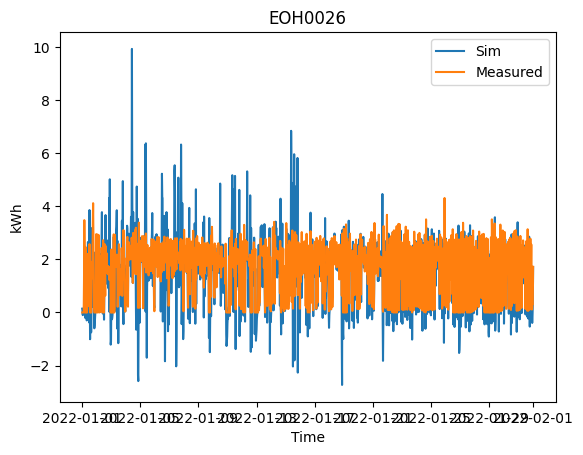

RMSE of q_hp: 1.5855688265203596


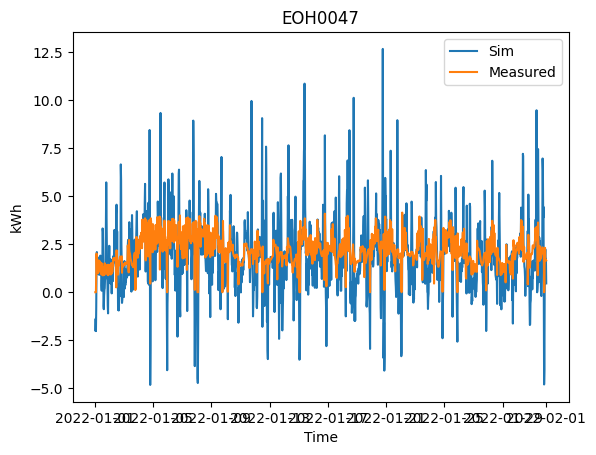

RMSE of q_hp: 1.1606672357498606


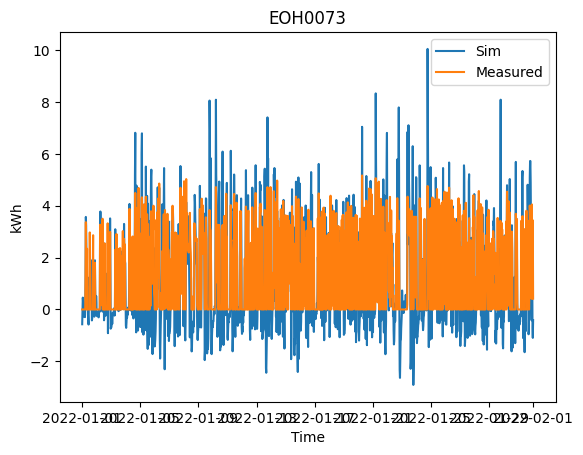

RMSE of q_hp: 1.572037415010537


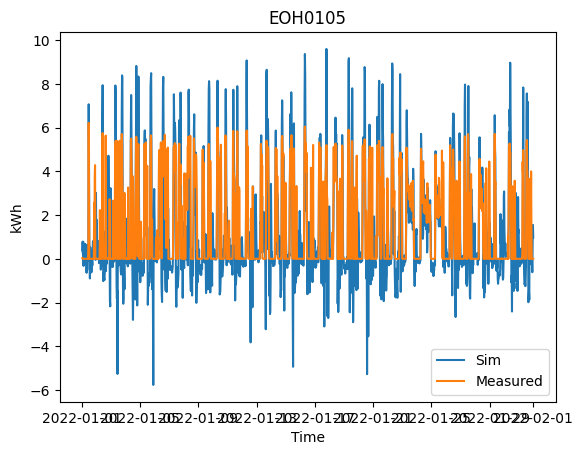

RMSE of q_hp: 0.733287982727825


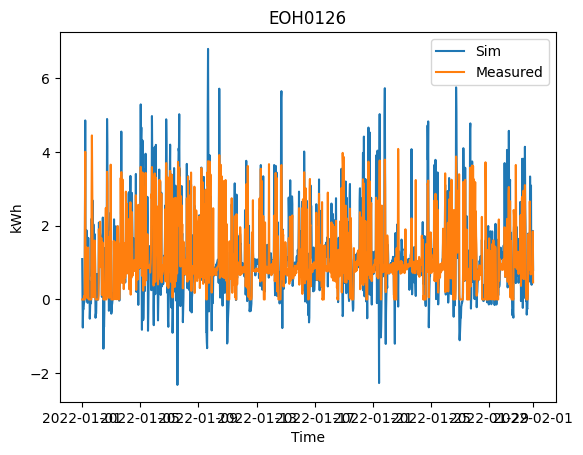

RMSE of q_hp: 1.045290553869416


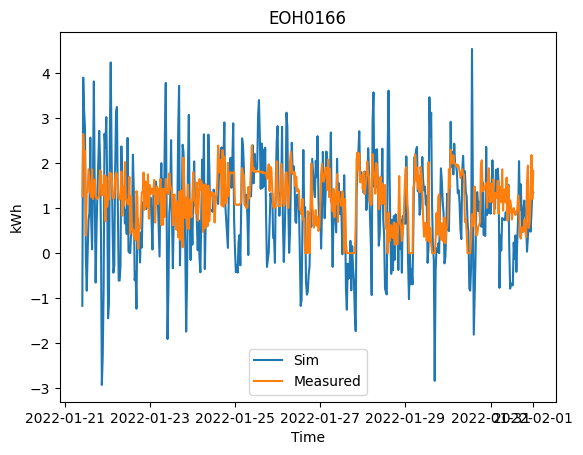

RMSE of q_hp: 4.776511555166854


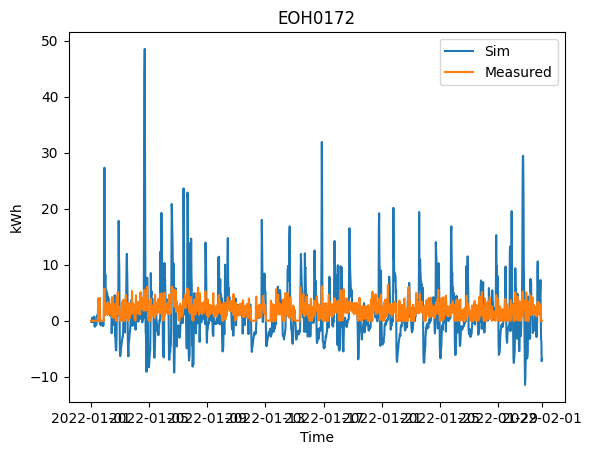

RMSE of q_hp: 1.1339231160386123


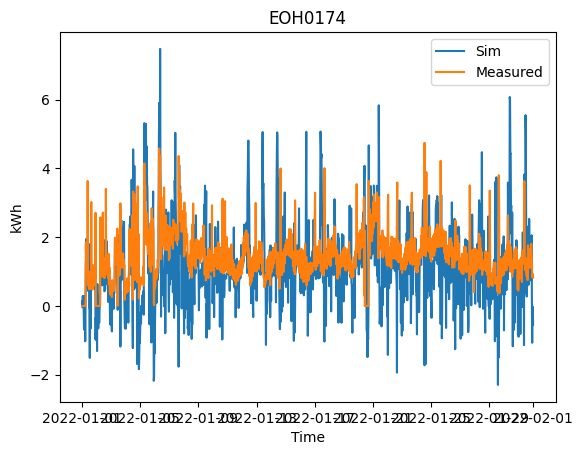

RMSE of q_hp: nan


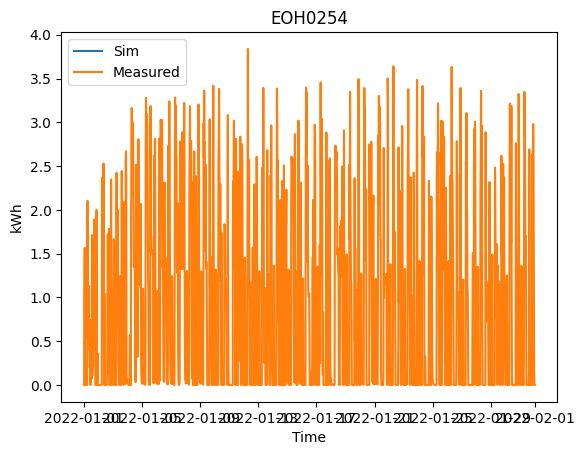

RMSE of q_hp: nan


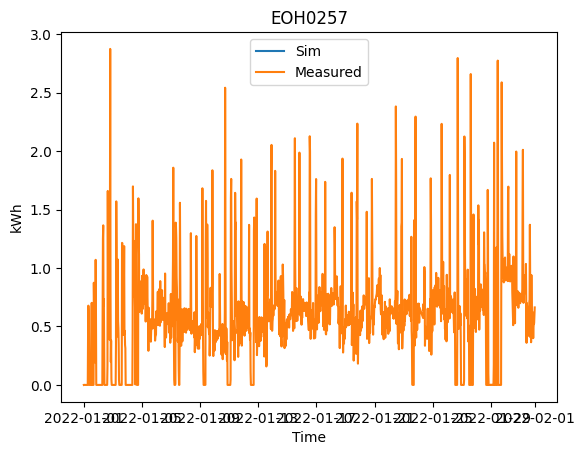

RMSE of q_hp: 10.539393028177377


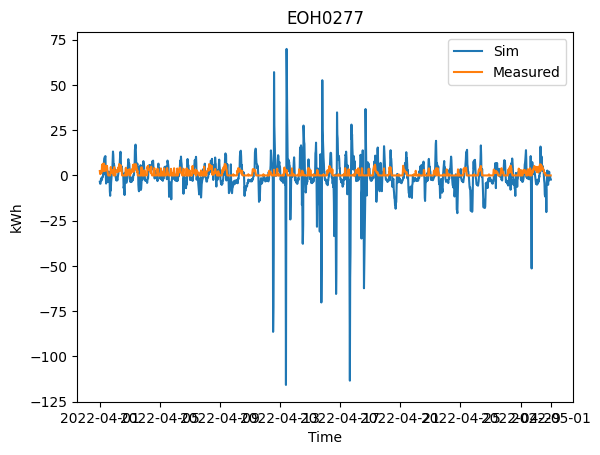

RMSE of q_hp: nan


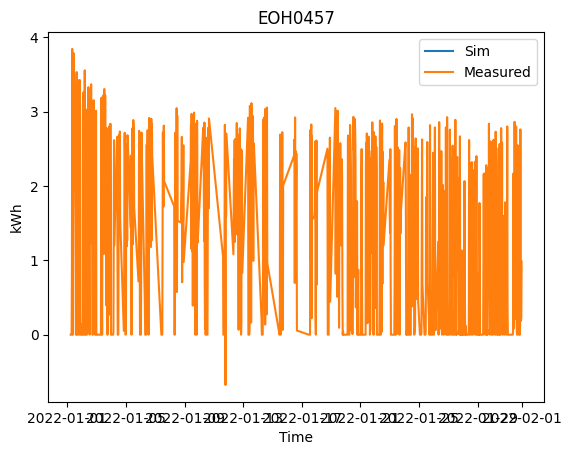

RMSE of q_hp: nan


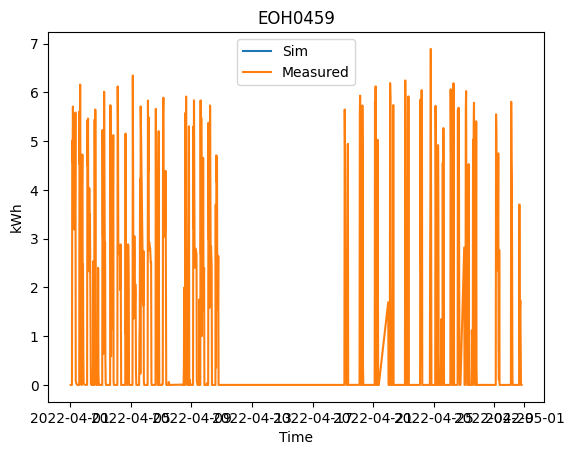

RMSE of q_hp: 4.528513934765947


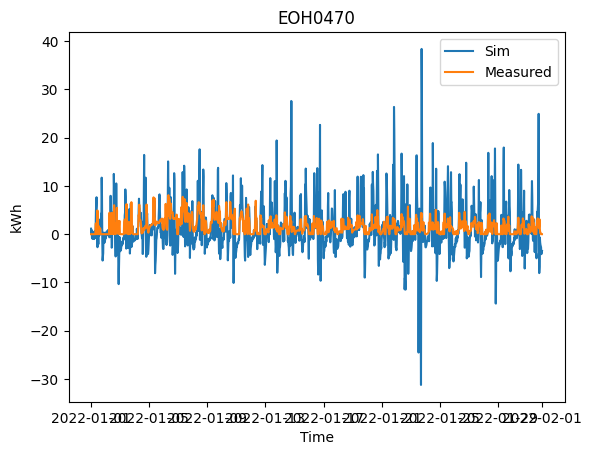

RMSE of q_hp: 1.093442733814976


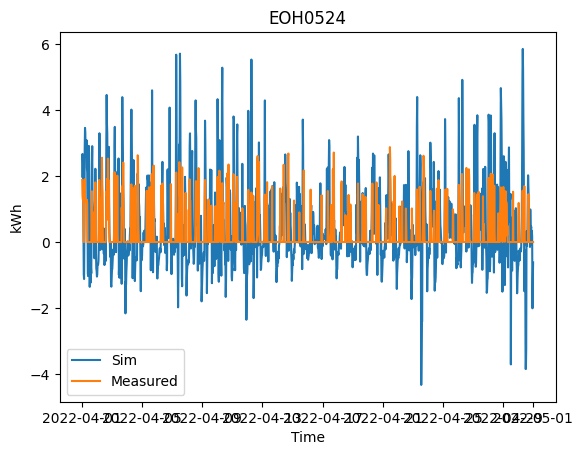

RMSE of q_hp: nan


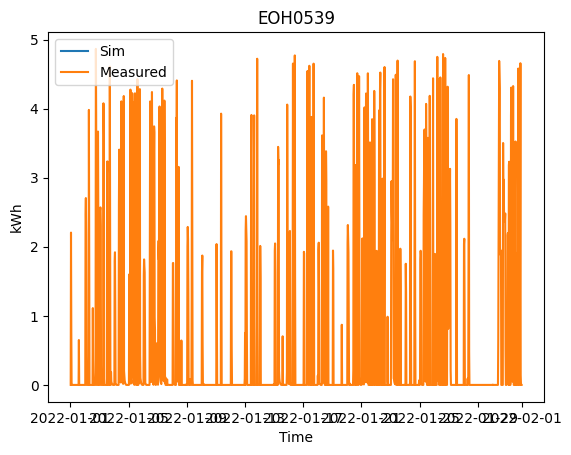

RMSE of q_hp: nan


KeyboardInterrupt: 

In [17]:
# ------- Look at heat supply performance in validation data ------
for id_use in unique_ids_trained:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s= df_id.w_s
    w_n = df_id.w_n
    t_start_val = df_id.val_start
    t_end_val = df_id.val_end
    t_start_train = df_id.train_start
    t_end_train = df_id.train_end

    
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.20 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    t_start = t_start_val
    t_end =  df_id.val_end
    df_q_opt = df_q_results[(df_q_results.index>=t_start) & (df_q_results.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['solarradiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["solarradiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    
    q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t  - w_s *  
            q_solar_val  - w * np.ones(len(T_a_val), )* delta_t )
    
    e_q = q_hat_sim - q_hp_val
    rmse_q_val = np.sqrt(np.mean(e_q**2))
    print(f"RMSE of q_hp: {rmse_q_val}")
    
    plt.plot(df_heating_val.index[1:],q_hat_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], q_hp_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("kWh")
    plt.title(f"{id_use}")
    plt.show()

In [ ]:
# -----Look at temperature tracking performance in the training --------------

for id_use in unique_ids_trained:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s = df_id.w_s
    w_n = df_id.w_n
    t_start_val = df_id.val_start
    t_end_val = df_id.val_end
    t_start_train = df_id.train_start
    t_end_train = df_id.train_end
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
         
    
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.20 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    # Validate results
    t_start = t_start_val
    t_end = t_end_val
    df_q_id_use = df_q_results[(df_q_results.index>=t_start) & (df_q_results.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['solarradiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["solarradiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    delta_T_i_sim = (delta_T_a_val / R_a *delta_t + q_hp_val + w_s* q_solar_val + w
                     * np
                     .ones(len(T_a_val), )* delta_t) / C
    
    # --- align time index with arrays ---
    time_index = df_heating_val.index[:-1]   # aligns with T_i_val, delta_T_i_sim

    T_i_sim = np.zeros_like(T_i_val)

    # initialize from first measurement
    T_prev = T_i_val[0]

    for i in range(len(T_i_val)):
        ts = time_index[i]

        # reset at midnight (00:00)
        if ts.hour == 0 and ts.minute == 0:
            T_prev = T_i_val[i]

        T_i_sim[i] = T_prev + delta_T_i_sim[i] * delta_t
        T_prev = T_i_sim[i]
    
    
    plt.plot(df_heating_val.index[1:],delta_T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], delta_T_i_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Delta T")
    plt.title(f"{id_use}")
    plt.show()
    
    plt.plot(df_heating_val.index[1:],T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], df_heating_val["Internal_Air_Temperature"]
             .iloc[1:].reset_index
           (drop=True).to_numpy(), label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Celsius")
    plt.title(f"{id_use}")
    plt.show()